<a href="https://colab.research.google.com/github/Evenjlin/deep-space-interference-ml/blob/main/notebooks/07_snr_estimation_and_grid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Cell 1 — self-contained bootstrap
from google.colab import userdata
import torch, os, sys

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
GITHUB_EMAIL = "evenjlinekka@gmail.com"
REPO_URL = f"https://{GITHUB_TOKEN}@github.com/Evenjlin/deep-space-interference-ml.git"

if not os.path.exists('/content/deep-space-interference-ml'):
    !git clone {REPO_URL} /content/deep-space-interference-ml
%cd /content/deep-space-interference-ml
!git config --global user.email "{GITHUB_EMAIL}"
!git config --global user.name "Evenjlin"
!git remote set-url origin {REPO_URL}
!git pull

!pip install -r requirements.txt -q
sys.path.insert(0, os.getcwd())

Device: cuda
/content/deep-space-interference-ml
Already up to date.


In [7]:
# Cell 2 — train the SNR regression CNN
import numpy as np
import torch
from src.channel import SignalConfig, generate_soi, generate_noise
from src.model import SNRRegressionCNN, complex_to_channels

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cfg = SignalConfig(fd_max=0.0)
rng = np.random.default_rng(42)
N_SYMBOLS = 64

def make_snr_sample(cfg, n_symbols, snr_db, rng):
    s, bits, fd, phi_m = generate_soi(cfg, n_symbols, rng)
    w = generate_noise(len(s), rng)
    rho_snr = 10 ** (snr_db / 10)
    return s + w / np.sqrt(rho_snr)

SNR_RANGE = (-15, 30)  # matches the grid range visible in Fig.5-7's axes
M_TRAIN, M_VAL = 6000, 1500

def build_snr_dataset(n):
    X, y = [], []
    for _ in range(n):
        snr_db = rng.uniform(*SNR_RANGE)
        x = make_snr_sample(cfg, N_SYMBOLS, snr_db, rng)
        X.append(complex_to_channels(x))
        y.append(snr_db)
    return np.stack(X).astype(np.float32), np.array(y, dtype=np.float32)

X_train, y_train = build_snr_dataset(M_TRAIN)
X_val, y_val = build_snr_dataset(M_VAL)
print("X_train:", X_train.shape, " y range:", y_train.min(), y_train.max())

X_train: (6000, 2, 512)  y range: -14.998053 29.982891


In [8]:
# Cell 3 — DEBUG LADDER for the regression CNN (same discipline as Step 5)
model = SNRRegressionCNN(cfg.NSPS).to(device)
tiny_x = torch.tensor(X_train[:8], device=device)
out = model(tiny_x)
print("TEST 1: output shape", out.shape, "-- expect (8,)")
assert out.shape == (8,)

tiny_y = torch.tensor(y_train[:8], device=device)
loss_fn = torch.nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss = loss_fn(out, tiny_y)
loss.backward(); opt.step(); opt.zero_grad()
print(f"TEST 2: one grad step OK, loss={loss.item():.4f}")

small_x = torch.tensor(X_train[:300], device=device)
small_y = torch.tensor(y_train[:300], device=device)
losses = []
for _ in range(10):
    opt.zero_grad()
    out = model(small_x)
    loss = loss_fn(out, small_y)
    loss.backward(); opt.step()
    losses.append(loss.item())
print("TEST 3/4 losses:", [f"{l:.2f}" for l in losses])
assert losses[-1] < losses[0], "Loss did not decrease -- stop, don't proceed"
print("Debug ladder PASSED.")

TEST 1: output shape torch.Size([8]) -- expect (8,)
TEST 2: one grad step OK, loss=262.4811
TEST 3/4 losses: ['224.14', '221.02', '217.97', '215.01', '212.19', '209.49', '206.92', '204.49', '202.18', '200.02']
Debug ladder PASSED.


Epoch 1/30  train_loss=182.886  val_loss=166.733  val_mae=10.189 dB
Epoch 2/30  train_loss=137.576  val_loss=99.712  val_mae=7.435 dB
Epoch 3/30  train_loss=85.670  val_loss=46.234  val_mae=4.797 dB
Epoch 4/30  train_loss=47.201  val_loss=24.479  val_mae=3.755 dB
Epoch 5/30  train_loss=24.477  val_loss=15.957  val_mae=3.198 dB
Epoch 6/30  train_loss=12.562  val_loss=8.885  val_mae=2.325 dB
Epoch 7/30  train_loss=7.385  val_loss=5.920  val_mae=1.859 dB
Epoch 8/30  train_loss=5.648  val_loss=4.156  val_mae=1.683 dB
Epoch 9/30  train_loss=5.089  val_loss=3.379  val_mae=1.426 dB
Epoch 10/30  train_loss=3.836  val_loss=3.106  val_mae=1.364 dB
Epoch 11/30  train_loss=3.219  val_loss=2.057  val_mae=1.078 dB
Epoch 12/30  train_loss=3.069  val_loss=2.978  val_mae=1.304 dB
Epoch 13/30  train_loss=2.541  val_loss=2.050  val_mae=1.147 dB
Epoch 14/30  train_loss=3.254  val_loss=1.558  val_mae=0.934 dB
Epoch 15/30  train_loss=2.647  val_loss=1.274  val_mae=0.889 dB
Epoch 16/30  train_loss=3.117  val

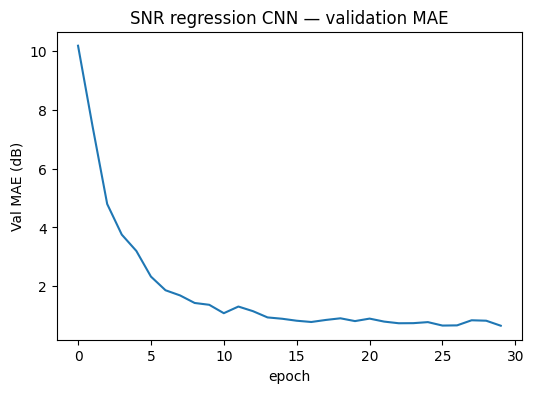

Final val MAE: 0.651 dB


In [9]:
# Cell 4 — full training
def train_snr_cnn(model, X_train, y_train, X_val, y_val, device,
                    epochs=30, batch_size=128, lr=1e-3, patience=5, seed=42):
    torch.manual_seed(seed)
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()
    Xt, yt = torch.tensor(X_train, device=device), torch.tensor(y_train, device=device)
    Xv, yv = torch.tensor(X_val, device=device), torch.tensor(y_val, device=device)

    history = {"train_loss": [], "val_loss": [], "val_mae": []}
    best_val, best_state, patience_ct = float("inf"), None, 0
    n = Xt.shape[0]

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n)
        ep_losses = []
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            opt.zero_grad()
            out = model(Xt[idx])
            loss = loss_fn(out, yt[idx])
            loss.backward(); opt.step()
            ep_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_out = model(Xv)
            val_loss = loss_fn(val_out, yv).item()
            val_mae = torch.mean(torch.abs(val_out - yv)).item()

        train_loss = float(np.mean(ep_losses))
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_mae"].append(val_mae)
        print(f"Epoch {epoch+1}/{epochs}  train_loss={train_loss:.3f}  val_loss={val_loss:.3f}  val_mae={val_mae:.3f} dB")

        if val_loss < best_val:
            best_val, best_state, patience_ct = val_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            patience_ct += 1
            if patience_ct >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    model.load_state_dict(best_state)
    return model, history

model = SNRRegressionCNN(cfg.NSPS)
model, history = train_snr_cnn(model, X_train, y_train, X_val, y_val, device)

import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(history["val_mae"])
plt.xlabel("epoch"); plt.ylabel("Val MAE (dB)")
plt.title("SNR regression CNN — validation MAE")
plt.savefig("figures/snr_cnn_training.png", dpi=150)
plt.show()

import os
os.makedirs("checkpoints", exist_ok=True)
torch.save(model.state_dict(), "checkpoints/snr_cnn.pt")
print(f"Final val MAE: {history['val_mae'][-1]:.3f} dB")